In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

# For reproducibility
torch.manual_seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadSelfAttention(nn.Module):
    """Masked multi-head self-attention."""
    def __init__(self, n_embd, n_head, block_size, dropout=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head

        # One projection for Q, K, V
        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

        # Causal mask (no looking ahead)
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(block_size, block_size)).unsqueeze(0).unsqueeze(0)
        )

    def forward(self, x):
        B, T, C = x.shape  # batch, time, channels

        # Project to Q, K, V and split heads
        qkv = self.qkv(x)  # (B, T, 3*C)
        q, k, v = qkv.chunk(3, dim=-1)

        # (B, T, C) -> (B, n_head, T, head_dim)
        def split_heads(t):
            return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        q = split_heads(q)
        k = split_heads(k)
        v = split_heads(v)



        att = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)  # (B, n_head, T, T)

        # Apply causal mask
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))

        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = att @ v  # (B, n_head, T, head_dim)

        # Merge heads: (B, n_head, T, head_dim) -> (B, T, C)
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        out = self.proj(out)
        out = self.dropout(out)
        return out


class FeedForward(nn.Module):
    """Position-wise feed-forward MLP."""
    def __init__(self, n_embd, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Transformer block: self-attention + MLP + residual + layer norm."""
    def __init__(self, n_embd, n_head, block_size, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ff = FeedForward(n_embd, dropout)

    def forward(self, x):
        # Pre-norm + residual for attention
        x = x + self.attn(self.ln1(x))
        # Pre-norm + residual for MLP
        x = x + self.ff(self.ln2(x))
        return x


class GPT(nn.Module):
    """Full GPT-style language model."""
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout=0.0):
        super().__init__()
        self.block_size = block_size


        # Stack of Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying (optional but common)
        self.token_embedding.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.block_size, "Sequence length exceeds block size."

        # Embeddings
        tok_emb = self.token_embedding(idx)                      # (B, T, n_embd)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)[None, :, :]       # (1, T, n_embd)

        x = self.drop(tok_emb + pos_emb)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.ln_f(x)
        logits = self.lm_head(x)                                 # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        """Autoregressive generation."""
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx



# **Architecture Description (Short Note)**

For this project, I implemented a compact GPT‑style Transformer designed for autoregressive language modeling. The model follows the standard components of the original GPT architecture: masked multi‑head self‑attention, a position‑wise feed‑forward MLP, residual connections, and layer normalization.

### **Model Dimensions**
- **Embedding dimension:** *n_embd = 256*  
  This size is large enough to capture meaningful token relationships while remaining computationally manageable for training on a single GPU or CPU.

- **Number of layers:** *n_layer = 4*  
  A 4‑layer Transformer provides enough depth to learn hierarchical patterns in text without excessive training time.

- **Number of attention heads:** *n_head = 4*  
  With 256 embedding dimensions, this gives each head a dimension of 64. This is a common and effective configuration that balances expressiveness and efficiency.

### **Context Length**
- **block_size = 128**  
  This determines the maximum sequence length the model can attend to. A context window of 128 tokens is sufficient for many small‑scale language modeling tasks and keeps memory usage low.

### **Attention Mechanism**
- The model uses **masked multi‑head self‑attention**, ensuring that each token can only attend to previous tokens. This enforces the autoregressive property required for next‑token prediction.

### **Feed‑Forward Network**
- Each Transformer block includes a **two‑layer MLP** with a hidden size of *4 × n_embd*, following the standard GPT design.  
- A GELU activation is used for smooth, stable training.

### **Normalization and Residuals**
- **Pre‑LayerNorm** is applied before both the attention and MLP sublayers.  
- **Residual connections** wrap each sublayer, improving gradient flow and stabilizing training.

### **Embeddings**
- The model uses **learned token embeddings** and **learned positional embeddings**, which are added together before entering the Transformer stack.

### **Output Layer**
- A final linear projection maps the hidden states back to vocabulary logits.  
- The token embedding matrix is **tied** to the output projection weights, reducing parameters and improving performance.



In [3]:


# Download Tiny Shakespeare (if not present)
if not os.path.exists('input.txt'):
    import urllib.request
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, 'input.txt')

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Character-level tokenization
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
stoi = {ch: i for i, ch in enumerate(chars)}

itos = {i: ch for i, ch in enumerate(chars)}

def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])

# Train/val split
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split, batch_size, block_size):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

Vocabulary size: 65


In [4]:
# Hyperparameters
batch_size = 32
block_size = 64
n_embd = 128
n_head = 4
n_layer = 4
max_iters = 3000          # Increase for better results (e.g., 5000+)
eval_interval = 200
learning_rate = 1e-3
dropout = 0.0

model = GPT(vocab_size, n_embd, n_head, n_layer, block_size, dropout).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

for iter in tqdm(range(max_iters)):
    if iter % eval_interval == 0 or iter == max_iters - 1:
        model.eval()
        with torch.no_grad():
            losses = []
            for _ in range(10):  # estimate val loss
                xb, yb = get_batch('val', batch_size, block_size)
                _, loss = model(xb, yb)
                losses.append(loss.item())
            val_loss = np.mean(losses)
            val_losses.append(val_loss)
            print(f"Step {iter}: val loss {val_loss:.4f}")

    model.train()
    xb, yb = get_batch('train', batch_size, block_size)
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

# # Plot losses
# plt.figure(figsize=(10,5))
# plt.plot(train_losses, label='Train Loss')
# plt.plot(range(0, len(train_losses), eval_interval), val_losses, label='Val Loss')
# plt.xlabel('Iteration')
# plt.ylabel('Loss')
# plt.legend()
# plt.title('Training and Validation Loss')
# plt.show()

Model parameters: 0.81M


  0%|          | 0/3000 [00:00<?, ?it/s]

Step 0: val loss 4.2258


  7%|▋         | 200/3000 [01:08<13:59,  3.33it/s]

Step 200: val loss 2.3771


...

 93%|█████████▎| 2800/3000 [15:55<01:20,  2.47it/s]

Step 2800: val loss 1.6354


100%|█████████▉| 2999/3000 [17:04<00:00,  3.20it/s]

Step 2999: val loss 1.6345


100%|██████████| 3000/3000 [17:05<00:00,  2.93it/s]


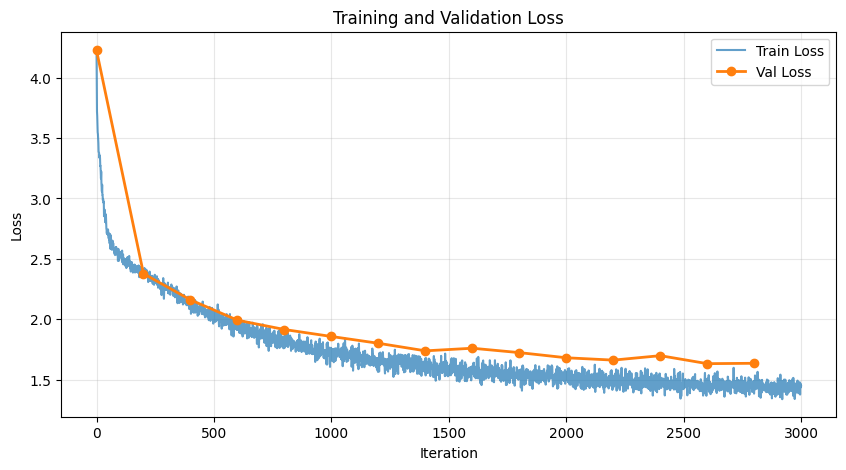

Final train loss: 1.4455
Final val loss:   1.6354
Number of val evaluations: 15


In [5]:
# Plot losses - FIXED
plt.figure(figsize=(10, 5))

# Plot training loss (every step)
plt.plot(train_losses, label='Train Loss', alpha=0.7)

# Plot validation loss at the correct x-coordinates
val_steps = list(range(0, len(train_losses), eval_interval))
if len(val_steps) > len(val_losses):
    val_steps = val_steps[:len(val_losses)]   # safety in case of early stop
elif len(val_losses) > len(val_steps):
    val_losses = val_losses[:len(val_steps)]  # trim extra if final eval added one more

plt.plot(val_steps, val_losses, label='Val Loss', marker='o', linewidth=2)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")
print(f"Number of val evaluations: {len(val_losses)}")

In [6]:
# Generate samples
context = torch.zeros((1, 1), dtype=torch.long, device=device)  # start with newline or empty
model.eval()
for _ in range(5):
    sample = model.generate(context, max_new_tokens=500, temperature=0.8)
    print(decode(sample[0].tolist()))
    print('='*80)


And then a king Tranio, I say the Duke of Warwick
Before my such our strenges necks, though parte.

Second Citizen:
Ay, some break of me, we war, since, who I here bier
I slew soul, and here for the other your honour,
But the robids of Oxford mine is.
Why, the feaiths of stratosh both himself and the carries
With the head father the much king of love,
In most cursies his sudded word it
a Gernmenten then armoor to the eaver unwel,
take at that the prett
To give thee on my simprice? wherein? the p

Be service:
Tell the instruptness Angelo; go it is,
And his prince of Edwardingmen, or great at with this
were were me not whetwisded, and me not
be you mad, how more still to me that all.

CORIOLANUS:
Your gods wife, middow'st: some father, ever
Me the whose.

PAULINA:
A queen ten it is batier, you are.

Servant:
I,
Hear me this eye.

ISABELLA:
Good give me steep thyself as dead, some prithes,
And beauted to himself dreamn'd the curse,
But if a temper, that you are; why love's nothing I
did 